In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
%matplotlib inline
from pandas import DataFrame
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
import math
import os

In [2]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

nsim = 10 # number of simulations

In [3]:
# Weights (unphos)

p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [4]:
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [5]:
ctd_p = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/ser5_dist/dat/ser5_ser7_dist.dat', sep = r'\s+')

In [6]:
pmean = np.average(ctd_p['SEP12-SER14'], weights=p_ctd_weights_combined[0])

pstd = np.sqrt(np.cov(ctd_p['SEP12-SER14'], aweights=p_ctd_weights_combined[0]))

print("pmean: {}".format(pmean))
print("pstd: {}".format(pstd))


pmean: 6.607929486266708
pstd: 1.2691174605485027


In [7]:
ctd_p

,#Frame,SEP12-SER14
0,1,8.1814
1,2,8.1284
2,3,8.0403
3,4,8.0606
4,5,7.7244
...,...,...
47999995,47999996,6.7038
47999996,47999997,6.2552
47999997,47999998,6.6098
47999998,47999999,6.5950


phosphoryalted vs unphosphorylated

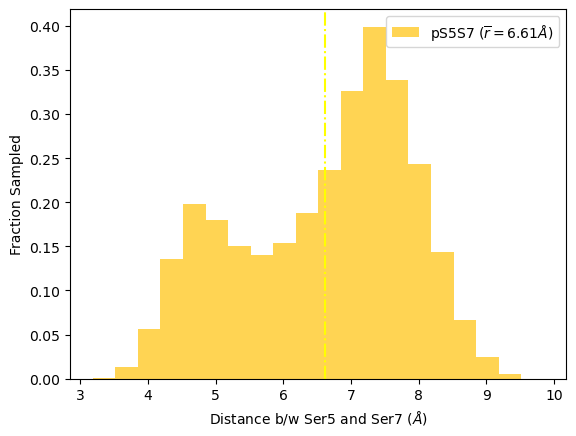

In [9]:
plt.hist(ctd_p['SEP12-SER14'], bins=20, weights = p_ctd_weights_combined[0], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean, 2)), alpha=0.7)
plt.axvline(pmean, color='yellow', ls='-.')

plt.ylabel('Fraction Sampled')
plt.xlabel('Distance b/w Ser5 and Ser7 ($\AA$)')
plt.legend(loc="upper right", fontsize=10)
plt.show()

In [9]:
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/analysis/turn/ctd_dihedral_Omega.dat', header=0, sep = r'\s+')

In [10]:
ctd_phos_omega_angles_raw.head()

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:13,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22
0,1,149.6943,174.4204,168.8683,-149.9181,177.5060,-159.4669,-159.2724,170.8971,167.8959,...,171.9545,-46.6864,177.4845,179.8129,-168.5947,159.5017,-163.2541,-167.9417,-57.2920,151.4641
1,2,151.6072,169.7661,157.9933,-144.9577,-178.3373,-159.2884,-169.2247,172.3083,164.3255,...,166.8214,-51.7775,176.9860,-158.2133,-177.7282,157.4615,-173.0805,171.1303,-47.8524,152.7084
2,3,145.2104,150.1280,168.5310,-150.4294,171.5608,-152.4731,-153.3966,-177.6363,177.3883,...,174.6519,-50.7529,178.2830,-163.9171,-169.0822,155.6675,-169.5220,-154.0863,-46.7623,161.5722
3,4,152.2419,161.1035,153.3329,-131.1403,167.8226,-148.4804,-144.0579,-169.6856,-177.4676,...,170.7676,-50.0442,176.5553,-179.0977,-154.1112,161.0077,-166.6328,-166.5948,-4.2173,172.3896
4,5,150.3117,168.7592,168.7656,-126.6141,162.7657,-161.9093,-165.6632,-162.0390,173.6437,...,174.3076,-51.7213,-175.8975,-170.3721,-170.9961,160.2525,-168.5060,-146.9860,-23.2039,175.7840


In [11]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

In [12]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()

In [13]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_1443263/1419004987.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [14]:
ctd_p = ctd_p.reset_index(drop=True)
ctd_p_cistrans = ctd_p.copy()
ctd_p_cistrans['cis/trans/neither'] = ctd_phos_omega_angles['omega:14']

In [15]:
ctd_p_cistrans['weights'] = p_ctd_weights_combined[0]

In [16]:
ctd_p_cistrans.head()

,#Frame,SEP12-SER14,cis/trans/neither,weights
0,1,8.1814,cis,2.954775e-08
1,2,8.1284,cis,3.422673e-08
2,3,8.0403,cis,3.474128e-08
3,4,8.0606,cis,3.702097e-08
4,5,7.7244,cis,2.175700e-08


In [17]:
ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis']

,#Frame,SEP12-SER14,cis/trans/neither,weights
0,1,8.1814,cis,2.954775e-08
1,2,8.1284,cis,3.422673e-08
2,3,8.0403,cis,3.474128e-08
3,4,8.0606,cis,3.702097e-08
4,5,7.7244,cis,2.175700e-08
...,...,...,...,...
29697875,29697876,7.4444,cis,7.010353e-10
29697877,29697878,7.3917,cis,6.106346e-10
29697884,29697885,7.0529,cis,6.223065e-10
29697964,29697965,7.5168,cis,9.624070e-10


In [18]:
ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans']

,#Frame,SEP12-SER14,cis/trans/neither,weights
4595,4596,7.6159,trans,4.175752e-08
5326,5327,7.6067,trans,3.047964e-08
5333,5334,7.5643,trans,3.536317e-08
5342,5343,7.2596,trans,3.319990e-08
5349,5350,7.6826,trans,3.610982e-08
...,...,...,...,...
47999995,47999996,6.7038,trans,6.879742e-32
47999996,47999997,6.2552,trans,6.879742e-32
47999997,47999998,6.6098,trans,6.879742e-32
47999998,47999999,6.5950,trans,6.879742e-32


## Pro6 in cis

In [19]:
pmean_cis = np.average((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['SEP12-SER14'], weights=(ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['weights'])

pstd_cis = np.sqrt(np.cov((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['SEP12-SER14'], aweights=(ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['weights']))

print("pmean: {}".format(pmean_cis))
print("pstd: {}".format(pstd_cis))

pmean: 6.72406228510904
pstd: 0.973953831358811


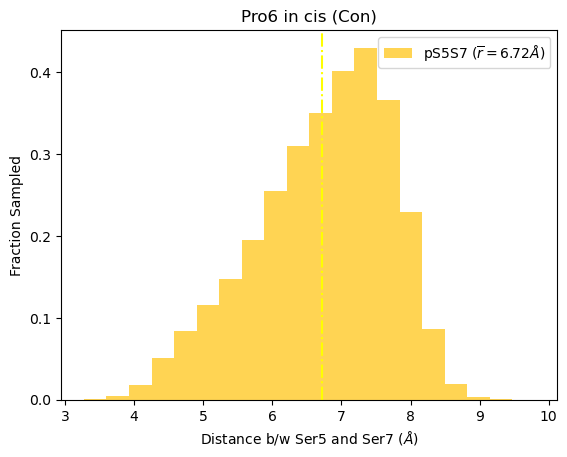

In [20]:
plt.hist((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['SEP12-SER14'], bins=20, weights = (ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_cis, 2)), alpha=0.7)

plt.axvline(pmean_cis, color='yellow', ls='-.')

plt.ylabel('Fraction Sampled')
plt.xlabel('Distance b/w Ser5 and Ser7 ($\AA$)')
plt.title('Pro6 in cis (Con)')
plt.legend(loc="upper right", fontsize=10)
plt.show()

## Pro6 in trans

In [21]:
pmean_trans = np.average((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['SEP12-SER14'], weights=(ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['weights'])

pstd_trans = np.sqrt(np.cov((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['SEP12-SER14'], aweights=(ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['weights']))

print("pmean: {}".format(pmean_trans))
print("pstd: {}".format(pstd_trans))

pmean: 6.586662812070996
pstd: 1.3280619591537777


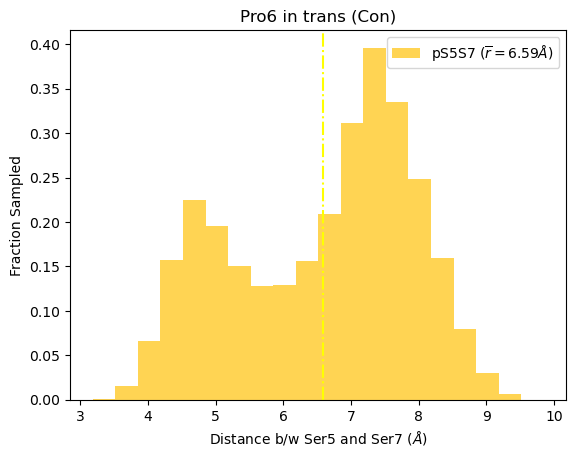

In [22]:
plt.hist((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['SEP12-SER14'], bins=20, weights = (ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", label=r"pS5S7 ($\overline{r} = $"+"{}$\AA$)".format(round(pmean_trans, 2)), alpha=0.7)

plt.axvline(pmean_trans, color='yellow', ls='-.')

plt.ylabel('Fraction Sampled')
plt.xlabel('Distance b/w Ser5 and Ser7 ($\AA$)')
plt.title('Pro6 in trans (Con)')
plt.legend(loc="upper right", fontsize=10)
plt.show()

## cis and trans together

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


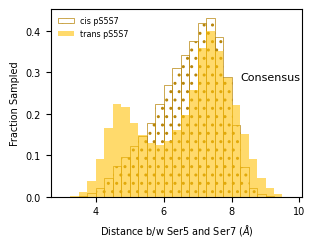

In [27]:
plt.figure()

binedges = np.arange(3,10,0.25)

n_density_cis, bins_cis, _cis = plt.hist((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['SEP12-SER14'], bins=binedges, weights = (ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'cis'])['weights'], density=True , color = '#FFC20A', hatch='..', linewidth=0.5, edgecolor="darkgoldenrod", fill=None, label=r"cis pS5S7".format(round(pmean_cis, 2)), alpha=1)

n_density_trans, bins_trans, _trans = plt.hist((ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['SEP12-SER14'], bins=binedges, weights = (ctd_p_cistrans[ctd_p_cistrans['cis/trans/neither'] == 'trans'])['weights'], density=True , color="#FFC20A", linewidth=0.5, label=r"trans pS5S7".format(round(pmean_trans, 2)), alpha=0.6)

plt.ylabel('Fraction Sampled', fontsize = 7)
plt.xlabel('Distance b/w Ser5 and Ser7 ($\AA$)', fontsize = 7)
#plt.title('Consensus Phosphorylated')
plt.legend(loc="upper left", fontsize=5.75, frameon=False)
plt.text(8.25, 0.3, 'Consensus', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('pS5-S7_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

In [24]:
# Set the threshold
threshold = 6

# Find the index of the first bin edge >= threshold
above_threshold_index = np.where(bins_cis >= threshold)[0][0]

# Sum the densities of the bins_cis above the threshold
sum_of_densities = np.sum(n_density_cis[above_threshold_index:])

# Calculate the width of a single bin
bin_width = bins_cis[1] - bins_cis[0]

# Calculate the proportion (percentage) of values above the threshold
# The proportion is the sum of the areas of the relevant bars
percentage_above_threshold = (sum_of_densities * bin_width) * 100

print(f"The total proportion (area) above {threshold} is: {sum_of_densities * bin_width:.2f}")
print(f"The percentage of values above {threshold} is: {percentage_above_threshold:.2f}%")

The total proportion (area) above 6 is: 0.77
The percentage of values above 6 is: 77.16%


In [25]:
# Set the threshold
threshold = 6

# Find the index of the first bin edge >= threshold
above_threshold_index = np.where(bins_trans >= threshold)[0][0]

# Sum the densities of the bins_trans above the threshold
sum_of_densities = np.sum(n_density_trans[above_threshold_index:])

# Calculate the width of a single bin
bin_width = bins_trans[1] - bins_trans[0]

# Calculate the proportion (percentage) of values above the threshold
# The proportion is the sum of the areas of the relevant bars
percentage_above_threshold = (sum_of_densities * bin_width) * 100

print(f"The total proportion (area) above {threshold} is: {sum_of_densities * bin_width:.2f}")
print(f"The percentage of values above {threshold} is: {percentage_above_threshold:.2f}%")

The total proportion (area) above 6 is: 0.67
The percentage of values above 6 is: 66.84%
